# 01 – Weather Station EDA
**Question:** What data do we have, is it usable, and how do campus thermal conditions vary across space and time?
Data: hourly 2025 readings from 40 NUS campus weather stations (City Syntax Lab).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RAW = Path("../data/raw")
files = sorted(RAW.glob("NUS_CAMPUS_WS*_2025_Hourly.csv"))
print(len(files), "files found")

40 files found


In [3]:
frames = []
for f in files:
    d = pd.read_csv(f, parse_dates=["Datetime"])
    d["Station"] = f.name.split("_")[2]   # e.g. "WS01"
    frames.append(d)

df = pd.concat(frames, ignore_index=True)

print(df.shape)
display(df.head())
df.info()

(349590, 11)


,Datetime,Latitude,Longitude,WindSpeed Ave (m/s),WindDir Ave (degrees),AirTemp Ave (C),RelHum Ave (%),AtmPress Ave (hPa),GlobalRad Ave (W/m2),Station,Rain Tot (mm)
0,2025-01-01 00:00:00,1.300666,103.771232,0.517148,131.040439,25.782881,91.496610,1008.647458,0.0,WS01,NaN
1,2025-01-01 01:00:00,1.300666,103.771232,0.554134,131.457858,25.839000,91.136667,1008.288333,0.0,WS01,NaN
2,2025-01-01 02:00:00,1.300666,103.771232,0.729291,134.155274,25.766500,91.260000,1007.598333,0.0,WS01,NaN
3,2025-01-01 03:00:00,1.300666,103.771232,0.538654,133.938148,25.509500,92.063333,1006.823333,0.0,WS01,NaN
4,2025-01-01 04:00:00,1.300666,103.771232,0.499675,127.333428,25.353833,92.536667,1006.203333,0.0,WS01,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349590 entries, 0 to 349589
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Datetime               349590 non-null  datetime64[ns]
 1   Latitude               349590 non-null  float64       
 2   Longitude              349590 non-null  float64       
 3   WindSpeed Ave (m/s)    335381 non-null  float64       
 4   WindDir Ave (degrees)  335381 non-null  float64       
 5   AirTemp Ave (C)        335381 non-null  float64       
 6   RelHum Ave (%)         335381 non-null  float64       
 7   AtmPress Ave (hPa)     335381 non-null  float64       
 8   GlobalRad Ave (W/m2)   325335 non-null  float64       
 9   Station                349590 non-null  object        
 10  Rain Tot (mm)          26280 non-null   float64       
dtypes: datetime64[ns](1), float64(9), object(1)
memory usage: 29.3+ MB


In [4]:
## 03. Dataset structure
df = df.rename(columns={
    "Datetime": "datetime",
    "Latitude": "lat",
    "Longitude": "lon",
    "WindSpeed Ave (m/s)": "wind_speed",
    "WindDir Ave (degrees)": "wind_dir",
    "AirTemp Ave (C)": "temp",
    "RelHum Ave (%)": "rh",
    "AtmPress Ave (hPa)": "pressure",
    "GlobalRad Ave (W/m2)": "solar",
    "Rain Tot (mm)": "rain",
})
df.columns.tolist()

['datetime',
 'lat',
 'lon',
 'wind_speed',
 'wind_dir',
 'temp',
 'rh',
 'pressure',
 'solar',
 'Station',
 'rain']

In [5]:
station_summary = (
    df.groupby("Station")
      .agg(rows=("datetime", "size"),
           first=("datetime", "min"),
           last=("datetime", "max"),
           lat=("lat", "first"),
           lon=("lon", "first"),
           n_locations=("lat", "nunique"))
)
station_summary["missing_rows"] = 8760 - station_summary["rows"]

print("Stations:", df["Station"].nunique())
print("Date range:", df["datetime"].min(), "→", df["datetime"].max())
display(station_summary.sort_values("missing_rows", ascending=False))

Stations: 40
Date range: 2025-01-01 00:00:00 → 2025-12-31 23:00:00


,rows,first,last,lat,lon,n_locations,missing_rows
Station,,,,,,,
WS38,8325,2025-01-01 00:00:00,2025-12-13 20:00:00,1.305473,103.773064,1,435
WS06,8443,2025-01-01 00:00:00,2025-12-18 18:00:00,1.298318,103.770400,1,317
WS17,8717,2025-01-01 00:00:00,2025-12-30 04:00:00,1.292331,103.774516,1,43
WS31,8748,2025-01-01 12:00:00,2025-12-31 23:00:00,1.296682,103.780151,1,12
WS20,8758,2025-01-01 00:00:00,2025-12-31 21:00:00,1.292916,103.779062,1,2
WS30,8759,2025-01-01 00:00:00,2025-12-31 22:00:00,1.295731,103.779872,1,1
WS01,8760,2025-01-01 00:00:00,2025-12-31 23:00:00,1.300666,103.771232,1,0
WS25,8760,2025-01-01 00:00:00,2025-12-31 23:00:00,1.297994,103.777999,1,0
WS26,8760,2025-01-01 00:00:00,2025-12-31 23:00:00,1.298145,103.777511,1,0


In [6]:
key = ["temp", "rh", "wind_speed", "wind_dir", "pressure", "solar"]
(df[key].isna().mean() * 100).round(2)

temp          4.06
rh            4.06
wind_speed    4.06
wind_dir      4.06
pressure      4.06
solar         6.94
dtype: float64

In [7]:
miss_station = (df[key].isna().groupby(df["Station"]).mean() * 100).round(1)
display(miss_station.sort_values("temp", ascending=False).head(10))

,temp,rh,wind_speed,wind_dir,pressure,solar
Station,,,,,,
WS11,26.6,26.6,26.6,26.6,26.6,26.6
WS34,21.1,21.1,21.1,21.1,21.1,21.1
WS32,19.5,19.5,19.5,19.5,19.5,10.5
WS14,16.4,16.4,16.4,16.4,16.4,15.9
WS07,11.2,11.2,11.2,11.2,11.2,11.3
WS33,10.2,10.2,10.2,10.2,10.2,10.2
WS17,9.7,9.7,9.7,9.7,9.7,9.6
WS15,9.3,9.3,9.3,9.3,9.3,9.3
WS31,8.4,8.4,8.4,8.4,8.4,8.4


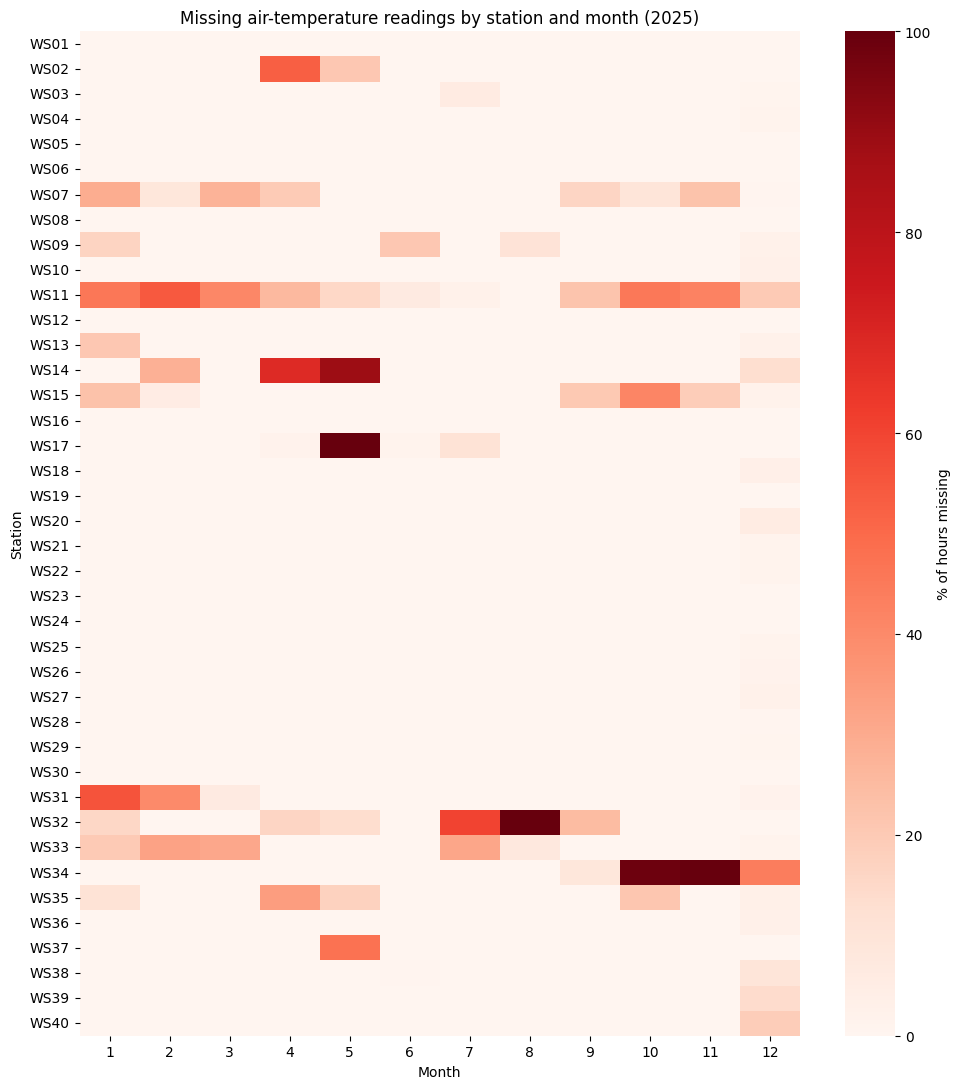

In [8]:
df["month"] = df["datetime"].dt.month
miss_month = (df["temp"].isna()
                .groupby([df["Station"], df["month"]]).mean()
                .unstack() * 100)

plt.figure(figsize=(10, 11))
sns.heatmap(miss_month, cmap="Reds", vmin=0, vmax=100,
            cbar_kws={"label": "% of hours missing"})
plt.title("Missing air-temperature readings by station and month (2025)")
plt.xlabel("Month")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

## 05. Data quality – implausible readings

In [9]:
df[key].describe().T[["min", "mean", "max"]].round(1)

,min,mean,max
temp,21.4,28.7,39.5
rh,37.6,80.5,99.5
wind_speed,0.0,0.7,17.0
wind_dir,0.0,185.3,360.0
pressure,459.9,1001.8,1016.4
solar,0.0,140.0,1500.0


In [10]:
limits = {
    "temp":       (20, 37),     # °C – Singapore's record high is about 37 °C
    "rh":         (0, 100),     # %
    "pressure":   (980, 1030),  # hPa – near sea level
    "wind_speed": (0, 15),      # m/s
    "solar":      (0, 1200),    # W/m² – clear-sky maximum near the equator
}

for var, (lo, hi) in limits.items():
    bad = df[(df[var] < lo) | (df[var] > hi)]
    print(f"{var:10s} outside {lo}–{hi}: {len(bad):5d} readings | "
          f"worst stations: {bad['Station'].value_counts().head(3).to_dict()}")

temp       outside 20–37:   294 readings | worst stations: {'WS22': 163, 'WS34': 29, 'WS26': 21}
rh         outside 0–100:     0 readings | worst stations: {}
pressure   outside 980–1030:  2868 readings | worst stations: {'WS17': 2868}
wind_speed outside 0–15:    21 readings | worst stations: {'WS17': 21}
solar      outside 0–1200:   802 readings | worst stations: {'WS23': 758, 'WS26': 32, 'WS07': 12}


In [11]:
night = df[df["datetime"].dt.hour.isin([20, 21, 22, 23, 0, 1, 2, 3, 4, 5])]
night_solar = (night.groupby("Station")["solar"]
                    .agg(mean="mean", max="max").round(1)
                    .sort_values("mean", ascending=False))
display(night_solar.head(8))
print("Median station's mean night-time solar:", night_solar["mean"].median())

,mean,max
Station,,
WS23,389.7,1500.0
WS39,206.4,223.1
WS32,143.3,152.9
WS07,53.5,1020.1
WS26,50.2,767.5
WS19,33.5,1013.5
WS11,0.4,5.6
WS14,0.4,11.0


Median station's mean night-time solar: 0.0


## 06. Cleaning rules

In [12]:
clean = df.copy()
log = []

def mask_to_nan(mask, col, rule):
    """Set flagged readings to NaN (blank) and record how many were changed."""
    n = int((mask & clean[col].notna()).sum())
    clean.loc[mask, col] = np.nan
    log.append({"rule": rule, "variable": col, "readings_set_to_NaN": n})

hour  = clean["datetime"].dt.hour
month = clean["datetime"].dt.month
is_night = hour.isin([20, 21, 22, 23, 0, 1, 2, 3, 4, 5])

# Station-specific solar faults (found in the night-time check)
mask_to_nan(clean["Station"].isin(["WS39", "WS32"]), "solar",
            "WS39/WS32 solar: constant night-time offset all year")
mask_to_nan((clean["Station"] == "WS23") & month.between(3, 9), "solar",
            "WS23 solar: faulty Mar–Sep (~800 W/m² at night)")

# General physical-plausibility rules
mask_to_nan(clean["solar"] > 1200, "solar", "solar > 1200 W/m²")
mask_to_nan(is_night & (clean["solar"] > 50), "solar",
            "solar > 50 W/m² at night (20:00–05:59)")
mask_to_nan(clean["pressure"] < 900, "pressure",
            "pressure < 900 hPa (WS17 fault, Jan–Apr)")
mask_to_nan(clean["wind_speed"] > 15, "wind_speed",
            "wind speed > 15 m/s (WS17 Dec, capped at 17.0)")

# Temperature: flagged, NOT removed
clean["temp_hot_flag"] = clean["temp"] > 37

quality_log = pd.DataFrame(log)
display(quality_log)
print("Temperature readings flagged (kept):", clean["temp_hot_flag"].sum())

quality_log.to_csv("../outputs/tables/quality_flags.csv", index=False)

,rule,variable,readings_set_to_NaN
0,WS39/WS32 solar: constant night-time offset al...,solar,16494
1,WS23 solar: faulty Mar–Sep (~800 W/m² at night),solar,3874
2,solar > 1200 W/m²,solar,44
3,solar > 50 W/m² at night (20:00–05:59),solar,2043
4,"pressure < 900 hPa (WS17 fault, Jan–Apr)",pressure,2868
5,"wind speed > 15 m/s (WS17 Dec, capped at 17.0)",wind_speed,21


Temperature readings flagged (kept): 294


## 07. Daily temperature cycle

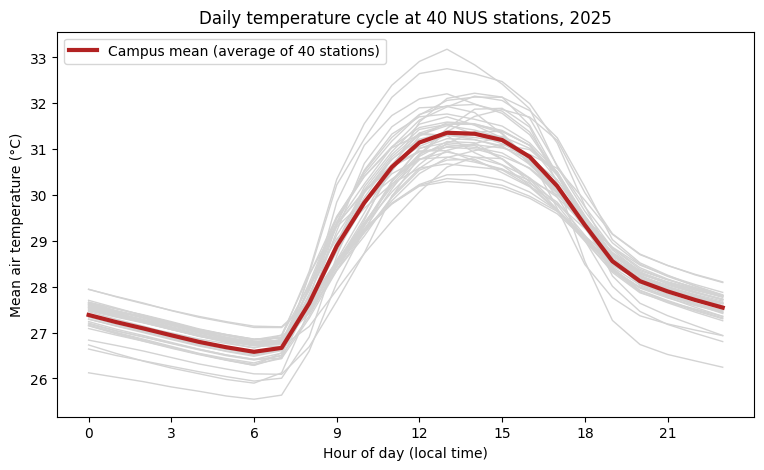

In [13]:
clean["hour"] = clean["datetime"].dt.hour
clean["month"] = clean["datetime"].dt.month

# rows = hour of day, columns = stations
hourly = clean.groupby(["Station", "hour"])["temp"].mean().unstack(0)
campus_hourly = hourly.mean(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(hourly.index, hourly.values, color="lightgrey", linewidth=1)
ax.plot(campus_hourly.index, campus_hourly.values, color="firebrick",
        linewidth=3, label="Campus mean (average of 40 stations)")
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("Hour of day (local time)")
ax.set_ylabel("Mean air temperature (°C)")
ax.set_title("Daily temperature cycle at 40 NUS stations, 2025")
ax.legend()
fig.savefig("../outputs/figures/diurnal_temperature.png", dpi=200, bbox_inches="tight")
plt.show()

In [14]:
spread = hourly.max(axis=1) - hourly.min(axis=1)

print(f"Campus mean: coolest {campus_hourly.min():.1f} °C at {campus_hourly.idxmin():02d}:00, "
      f"warmest {campus_hourly.max():.1f} °C at {campus_hourly.idxmax():02d}:00")
print(f"Spread between hottest and coolest station at 04:00: {spread[4]:.2f} °C")
print(f"Spread between hottest and coolest station at 14:00: {spread[14]:.2f} °C")
print("Hottest station at 14:00:", hourly.loc[14].idxmax(),
      "| coolest:", hourly.loc[14].idxmin())
print("Hottest station at 04:00:", hourly.loc[4].idxmax(),
      "| coolest:", hourly.loc[4].idxmin())

Campus mean: coolest 26.6 °C at 06:00, warmest 31.4 °C at 13:00
Spread between hottest and coolest station at 04:00: 1.63 °C
Spread between hottest and coolest station at 14:00: 2.59 °C
Hottest station at 14:00: WS22 | coolest: WS16
Hottest station at 04:00: WS38 | coolest: WS20
